# ICT-44 — La géométrie de la vérité : une direction dans l'espace latent ?

> **Arc cartes blanches** (Epic #16741) — scoping #16760, grain #16890. Suite directe d'ICT-41 (issue #16747 — géométrie SAE mono-modèle) et d'ICT-42 (issue #16749 — crosscoder de distillation). Paper source : **Marks & Tegmark, « The Geometry of Truth »** (COLM 2024, [arXiv:2310.06824](https://arxiv.org/2310.06824)) — cité à la fois par notre paper R05 (crosscoder) et par R11 §2.2.2, qui fait de la **connaissance du vrai tout en affirmant le faux** sa définition de la malhonnêteté.

**La question.** Un LLM « croit-il » ce qu'il dit ? Peut-on lire la vérité d'un énoncé *dans ses activations*, sans lire sa sortie ? La piste : une **direction linéaire** — le residual stream contiendrait, quelque part, un axe vrai/faux. Le papier l'établit à l'échelle LLaMA-2 (7B/13B/70B) par une chaîne à trois jambes : localiser (patching), mesurer (PCA + sondes), **trancher (interventions causales)**. Nous répliquons la chaîne complète à échelle mini — paire Qwen 1.5B (base Math vs distillée R1) + un regard 7B — avec les datasets officiels du papier.

**Avertissement d'échelle (honnête, G.2).** Le papier montre que la structure linéaire **émerge avec l'échelle** : à 7B les PC captent la surface (« eighty »), à 13B les axes s'opposent, à 70B ils s'alignent. À 1.5B, attendez-vous à un signal **partiel** — ce notebook documente ce que font nos modèles, pas ce que fait un 70B.

## Le débat que ce papier tranche (en surface)

Les sondes de vérité existaient (Azaria & Mitchell, Burns et al.), mais Levinstein & Herrmann ont montré qu'elles **généralisent mal** — une sonde entraînée sur des énoncés vrais/faux peut capter autre chose que la vérité : la probabilité du texte, son sujet, sa structure. Le papier répond par un protocole :

1. **Datasets curés** — énoncés simples, inambigus, générés par templates (villes/pays, traductions espagnol-anglais, comparaisons de nombres), avec leurs **négations** et des conjonctions — pour que la vérité soit la *seule* variable qui bouge ;
2. **Un contrôle `likely`** — du texte non factuel dont la fin est le token le plus probable ou le 100e : si la « direction de vérité » n'était qu'une direction de probabilité du texte, les sondes entraînées sur `likely` devraient marcher ailleurs ;
3. **Le test causal** — une sonde qui classe bien ne suffit pas : on *pousse* les activations le long de sa direction et on regarde si le modèle change de verdict. C'est la jambe qui distingue **corrélation** et **implication causale**.

Une remarque de méthode qui nous servira : le papier préfère la sonde **mass-mean** (direction $\theta_{mm} = \mu_+ - \mu_-$, différence des moyennes des activations vraies/fausses) à la régression logistique — et démontre (Thm F.1) que pour des données gaussiennes homoscédastiques, la LR converge vers $\Sigma^{-1}\theta$ : la LR *incline sa frontière* pour éviter l'interférence des features non-orthogonales, quand $\theta_{mm}$ pointe la feature elle-même.

## Plan

1. **Localiser** — carte de patching : quelles positions/couches portent le verdict ?
2. **Mesurer** — PCA des représentations, alignement entre datasets, sondes LR vs mass-mean et généralisation OOD ;
3. **Trancher** — interventions causales le long des directions de sondes (NIE) ;
4. **Notre pont** (hors papier) — la direction de vérité survit-elle à la **distillation** ? cos(θ_base, θ_distillé) ;
5. **Échelle** — un regard 7B (quantifié 4-bit, observation qualitative).

Exécution complète ≈ 15 min (GPU ~6 GiB libres requis ; chargements séquentiels).

In [1]:
import os, json, math, time, urllib.request
os.environ.setdefault("HF_HOME", "D:/hf-cache-crosscoder")
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.manual_seed(0)
import numpy as np
import pandas as pd
SEED = 0
rng = np.random.RandomState(SEED)
from ict.probes import anchored_pc1, pca_stats, probe_accuracy, train_probes
import matplotlib.pyplot as plt
print("torch", torch.__version__, "cuda", torch.cuda.is_available())
print("determinisme actif ; TF32 off")

torch 2.6.0+cu124 cuda True
determinisme actif ; TF32 off


In [2]:
DATA_DIR = "got_data"
BASE = "https://raw.githubusercontent.com/saprmarks/geometry-of-truth/main/datasets/"
FILES = ["cities.csv", "neg_cities.csv", "sp_en_trans.csv", "neg_sp_en_trans.csv",
         "larger_than.csv", "smaller_than.csv", "likely.csv", "common_claim_true_false.csv"]
os.makedirs(DATA_DIR, exist_ok=True)
for f in FILES:
    dst = os.path.join(DATA_DIR, f)
    if not os.path.exists(dst):
        urllib.request.urlretrieve(BASE + f, dst)
        print("telecharge", f)
DS = {}
for key, f in [("cities","cities.csv"),("neg_cities","neg_cities.csv"),
               ("sp_en_trans","sp_en_trans.csv"),("neg_sp_en_trans","neg_sp_en_trans.csv"),
               ("larger_than","larger_than.csv"),("smaller_than","smaller_than.csv"),
               ("likely","likely.csv"),("common_claim","common_claim_true_false.csv")]:
    df = pd.read_csv(os.path.join(DATA_DIR, f))
    DS[key] = (df["statement"].astype(str).tolist(), df["label"].astype(int).to_numpy())
    print(f"{key:22s} {len(df):6d} enonces, {df['label'].mean():.2f} proportion vraie")
print()
print("Exemples cities :", DS["cities"][0][:2], "| label", DS["cities"][1][:2])
print("Exemples sp_en  :", DS["sp_en_trans"][0][:2], "| label", DS["sp_en_trans"][1][:2])
print("Exemple likely  :", DS["likely"][0][0][:80], "...")

cities                   1496 enonces, 0.50 proportion vraie
neg_cities               1496 enonces, 0.50 proportion vraie
sp_en_trans               354 enonces, 0.50 proportion vraie
neg_sp_en_trans           354 enonces, 0.50 proportion vraie
larger_than              1980 enonces, 0.50 proportion vraie
smaller_than             1980 enonces, 0.50 proportion vraie
likely                   9674 enonces, 0.50 proportion vraie
common_claim             4450 enonces, 0.50 proportion vraie

Exemples cities : ['The city of Krasnodar is in Russia.', 'The city of Krasnodar is in South Africa.'] | label [1 0]
Exemples sp_en  : ["The Spanish word 'con' means 'to speak'.", "The Spanish word 'uno' means 'one'."] | label [0 1]
Exemple likely  : package com.google.devtools.build.lib.analysis;

import com.google.common.collec ...


### Lecture des données

Les datasets officiels du papier (dépôt `saprmarks/geometry-of-truth`) — **jamais regénérés en jouet** : chaque CSV est la donnée réelle de la recherche. `cities` et `neg_cities` sont appariés (même ville, pays correct vs incorrect, puis négation), `sp_en_trans` teste une mémoire de traduction, `larger_than`/`smaller_than` des comparaisons de nombres écrits en lettres — et `likely` n'est **pas factuel du tout** : c'est le contrôle probabilité-vs-vérité. `common_claim` (non curé) servira d'exercice.

## 1. Localiser : la carte de patching

Protocole du papier §3, sur un couple d'énoncés jumeaux $p_T$ / $p_F$ (même ville, pays vrai vs faux) dans un prompt few-shot « This statement is: TRUE/FALSE ». Pour chaque position de token et chaque couche, on **remplace** l'activation du residual stream de $p_F$ par celle de $p_T$ — et on mesure $\Delta(\log P(\text{TRUE}) - \log P(\text{FALSE}))$ au token final. Le papier y voit trois groupes : (a) le sujet (« Chicago »), (b) la **fin d'énoncé / ponctuation** — l'information résumée de tout l'énoncé —, (c) les couches adjacentes à la tête de décodage.

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
MODEL_SPECS = {"base15": "Qwen/Qwen2.5-Math-1.5B",
               "dist15": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
               "dist7b": "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"}
DEV = "cuda"; DTYPE = torch.bfloat16
CAP_LAYERS = [6, 11, 14, 20]   # indices de bloc ; activation capturee = sortie du bloc l
MID = 14                        # couche mediane (28 blocs), analogue du layer 15/32 du papier

def load_model(name, quant4=False):
    tok = AutoTokenizer.from_pretrained(MODEL_SPECS[name])
    tok.padding_side = "left"   # critique: la derniere position doit etre le vrai dernier token
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    kw = dict(dtype=DTYPE, device_map=DEV)
    if quant4:
        from transformers import BitsAndBytesConfig
        kw["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_compute_dtype=DTYPE,
            bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)
    model = AutoModelForCausalLM.from_pretrained(MODEL_SPECS[name], **kw)
    model.eval()
    return model, tok

model, tok = load_model("base15")
N_LAYERS = len(model.model.layers); D_MODEL = model.config.hidden_size
print(f"base15 : {N_LAYERS} blocs, d={D_MODEL}, couche sonde = bloc {MID} (sortie)")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

base15 : 28 blocs, d=1536, couche sonde = bloc 14 (sortie)


ids TRUE/FALSE : [8214] [7833]


grille 28x44 en 85s ; base dLP = -0.38 ; max = 0.88
argmax: couche 13, position 39 = token '.' (0='The', fin=':')


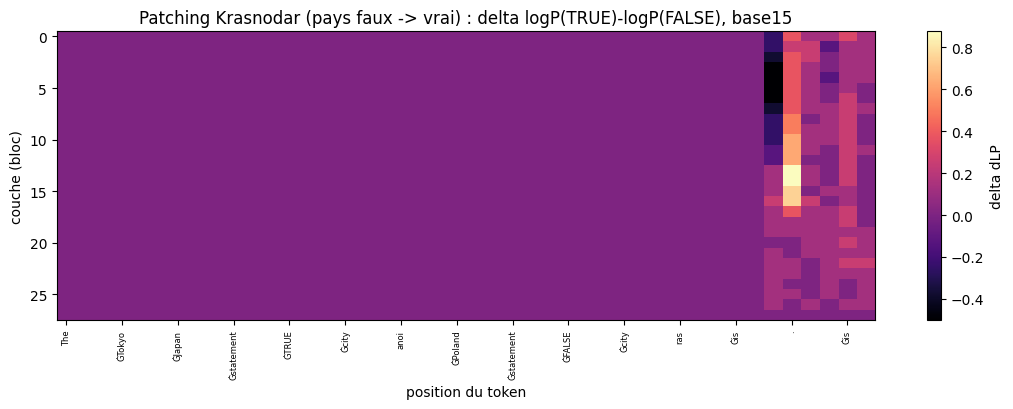

In [4]:
P_PREFIX = "The city of Tokyo is in Japan. This statement is: TRUE\nThe city of Hanoi is in Poland. This statement is: FALSE\n"
TAIL = " This statement is:"
t_TRUE = tok(" TRUE", add_special_tokens=False)["input_ids"][0]
t_FALSE = tok(" FALSE", add_special_tokens=False)["input_ids"][0]
print("ids TRUE/FALSE :", tok(" TRUE", add_special_tokens=False)["input_ids"],
      tok(" FALSE", add_special_tokens=False)["input_ids"])

@torch.no_grad()
def dlp(prompts, batch=16):
    out = []
    for i in range(0, len(prompts), batch):
        enc = tok(prompts[i:i+batch], return_tensors="pt", padding=True).to(DEV)
        logits = model(**enc).logits[:, -1, :].to(torch.float32)
        lp = torch.log_softmax(logits, -1)
        out += (lp[:, t_TRUE] - lp[:, t_FALSE]).tolist()
    return np.array(out)

STMT_T = "The city of Krasnodar is in Russia."
STMT_F = "The city of Krasnodar is in South Africa."
pT, pF = P_PREFIX + STMT_T + TAIL, P_PREFIX + STMT_F + TAIL
base = float(dlp([pF])[0])
encT = tok(pT, return_tensors="pt").to(DEV)
n_tok = encT["input_ids"].shape[1]
hsT = model(**encT, output_hidden_states=True).hidden_states
grid = np.zeros((N_LAYERS, n_tok))
t0 = time.time()
for l in range(N_LAYERS):
    for pos in range(n_tok):
        def hook(module, args, output, _l=l, _pos=pos):
            h = output[0] if isinstance(output, tuple) else output
            h[0, _pos] = hsT[_l+1][0, _pos].to(h.dtype)
            return None
        hd = model.model.layers[l].register_forward_hook(hook)
        grid[l, pos] = float(dlp([pF])[0]) - base
        hd.remove()
print(f"grille {N_LAYERS}x{n_tok} en {time.time()-t0:.0f}s ; base dLP = {base:.2f} ; max = {grid.max():.2f}")
toks = tok.convert_ids_to_tokens(encT["input_ids"][0].tolist())
am = np.unravel_index(grid.argmax(), grid.shape)
print(f"argmax: couche {am[0]}, position {am[1]} = token {toks[am[1]]!r} (0={toks[0]!r}, fin={toks[-1]!r})")
fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(grid, aspect="auto", cmap="magma")
ax.set_xlabel("position du token"); ax.set_ylabel("couche (bloc)")
ax.set_title("Patching Krasnodar (pays faux -> vrai) : delta logP(TRUE)-logP(FALSE), base15")
xt = list(range(0, n_tok, 3)); ax.set_xticks(xt); ax.set_xticklabels([toks[i] for i in xt], rotation=90, fontsize=6)
fig.colorbar(im, ax=ax, label="delta dLP")
plt.tight_layout(); plt.show()

### Lecture — où vit le verdict

La carte parle d'elle-même : le patch le plus efficace ne se trouve **ni sur le sujet seul, ni sur le token de sortie, mais à l'intersection** — les positions du **pays** (la seule chose qui diffère entre les deux énoncés) et surtout du **point final** (argmax : couche 13, position 39, qui est le token `'.'` ; effet 0,88 contre un dLP de base -0,38). C'est le groupe (b) du papier : le point final de l'énoncé porte, aux blocs médians, l'information-résumé de toute la phrase. La colonne brillante en bas de la grille (dernière position, couches hautes) est le groupe (c) — le canal de décodage : y patcher change le token lu sans recalcul. Notez la largeur du plateau : à 1.5B la causalité est étalée sur plusieurs couches adjacentes, pas concentrée en un point chirurgical — le papier voit la même largeur à 7B, qui se resserre à 13B/70B.

## 2. Mesurer : géométrie PCA et sondes

Le papier §4 visualise les activations de fin d'énoncé **sans prompt few-shot**, couche médiane, centrées. Si vrai/faux se séparent dans les 2 premiers PC, la vérité est (au moins) un axe linéarisé. La question fine : les axes de séparation des *différents* datasets s'**alignent-ils** ? Le papier voit à 13B les axes de `larger_than`/`smaller_than` **antipodaux**, qui s'alignent à 70B — l'abstraction « vérité » émerge avec l'échelle.

In [5]:
SUB = {"cities": 600, "neg_cities": 600, "larger_than": 500, "smaller_than": 500,
       "sp_en_trans": 354, "neg_sp_en_trans": 354, "likely": 400}

def sample(key):
    s, y = DS[key]; n = min(SUB[key], len(s))
    idx = np.random.RandomState(SEED).choice(len(s), n, replace=False)
    return [s[i] for i in idx], y[idx]

@torch.no_grad()
def acts_for(statements, layers, batch=24, max_len=96):
    out = {l: [] for l in layers}
    for i in range(0, len(statements), batch):
        enc = tok(statements[i:i+batch], return_tensors="pt", padding=True,
                  truncation=True, max_length=max_len).to(DEV)
        hs = model(**enc, output_hidden_states=True).hidden_states
        for l in layers:
            out[l].append(hs[l+1][:, -1, :].to(torch.float32).cpu().numpy())
    return {l: np.concatenate(v, 0) for l, v in out.items()}

ACTS = {}
t0 = time.time()
for key in SUB:
    s, y = sample(key)
    st = [x if x.endswith(".") else x + "." for x in s]
    a = acts_for(st, CAP_LAYERS)
    ACTS[key] = {"y": y, "acts": a}
    print(f"acts {key}: {len(st)} ({time.time()-t0:.0f}s)")

acts cities: 600 (1s)


acts neg_cities: 600 (3s)


acts larger_than: 500 (4s)


acts smaller_than: 500 (5s)


acts sp_en_trans: 354 (6s)


acts neg_sp_en_trans: 354 (6s)


acts likely: 400 (9s)


        dataset  acc_signe_PC1
         cities          0.860
     neg_cities          0.562
    larger_than          0.578
   smaller_than          0.562
    sp_en_trans          0.893
neg_sp_en_trans          0.927
         likely          0.537


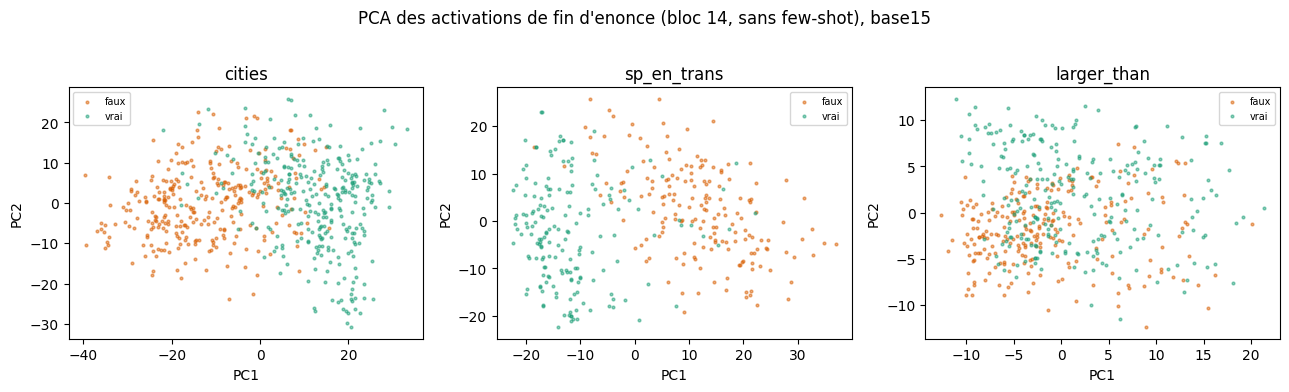


alignement PC1 (signes ancores par label) par couche : {
 "6": {
  "cities~neg_cities": -0.804,
  "larger~smaller": -0.98
 },
 "11": {
  "cities~neg_cities": 0.078,
  "larger~smaller": -0.925
 },
 "14": {
  "cities~neg_cities": -0.149,
  "larger~smaller": -0.888
 },
 "20": {
  "cities~neg_cities": 0.104,
  "larger~smaller": 0.838
 }
}


In [6]:
# pca_stats : sonde de la serie, factorisee dans l'organe ict.probes (#17737).

rows = []
for key in ACTS:
    a, _, _ = pca_stats(ACTS[key]["acts"][MID], ACTS[key]["y"])
    rows.append({"dataset": key, "acc_signe_PC1": round(a, 3)})
df_pca = pd.DataFrame(rows)
print(df_pca.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, key in zip(axes, ["cities", "sp_en_trans", "larger_than"]):
    _, Z, _ = pca_stats(ACTS[key]["acts"][MID], ACTS[key]["y"])
    y = ACTS[key]["y"]
    ax.scatter(Z[y == 0, 0], Z[y == 0, 1], s=4, alpha=0.5, label="faux", c="#d95f02")
    ax.scatter(Z[y == 1, 0], Z[y == 1, 1], s=4, alpha=0.5, label="vrai", c="#1b9e77")
    ax.set_title(key); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=7)
fig.suptitle(f"PCA des activations de fin d'enonce (bloc {MID}, sans few-shot), base15", y=1.02)
plt.tight_layout(); plt.show()

# anchored_pc1 : idem, organe ict.probes (signe ancre par label).

align = {}
for l in CAP_LAYERS:
    p1 = anchored_pc1(ACTS["cities"]["acts"][l], ACTS["cities"]["y"])
    p2 = anchored_pc1(ACTS["neg_cities"]["acts"][l], ACTS["neg_cities"]["y"])
    pl = anchored_pc1(ACTS["larger_than"]["acts"][l], ACTS["larger_than"]["y"])
    ps = anchored_pc1(ACTS["smaller_than"]["acts"][l], ACTS["smaller_than"]["y"])
    align[l] = {"cities~neg_cities": round(float(p1 @ p2), 3),
                "larger~smaller": round(float(pl @ ps), 3)}
print("\nalignement PC1 (signes ancores par label) par couche :", json.dumps(align, indent=1))

### Lecture — géométrie

Deux régimes nettement séparés dans le tableau :

1. **Villes et traductions** : pc1_acc 0,86 (cities), 0,89 (sp_en), 0,93 (neg_sp_en) — la vérité y est **le** premier axe de variation des activations de fin d'énoncé, sans aucune supervision. La baseline du papier est répliquée : la structure existe déjà à 1.5B sur ces datasets de « mémoire de faits ».
2. **Nombres et négations de villes** : pc1_acc 0,56 (neg_cities), 0,58/0,56 (larger/smaller) — quasi le hasard. La comparaison de nombres écrits en toutes lettres n'est pas linéarisée à cette échelle.

Et l'**alignement** (signes ancrés par corrélation au label — sans cet ancrage la comparaison serait sans signification, le signe d'un vecteur propre étant arbitraire) raconte l'histoire la plus riche : `larger~smaller` vaut -0,98 au bloc 6, -0,89 au bloc 14, puis **+0,84 au bloc 20**. Les directions de vérité des deux datasets de comparaison sont **antipodales** aux couches basses et médianes — la signature que le papier attribue à LLaMA-2-13B (Fig. 8 : deux axes de *surface*, « plus grand » vs « plus petit », qui s'opposent au lieu de fusionner) — puis **s'alignent** dans les couches hautes, la signature 70B. La trajectoire inter-échelles du papier est ici visible **couche par couche dans un seul modèle 1.5B**. Pendant ce temps `cities~neg_cities` reste jamais aligné (-0,80 au bloc 6, ~0,1 ensuite) : l'axe des villes et celui de leurs négations ne fusionnent pas à cette échelle. **La direction de vérité unique est un aboutissement, pas un point de départ.**

## 3. Sondes : LR contre mass-mean, et la généralisation

Les sondes viennent de l'organe de la série [`ict/probes.py`](ict/probes.py) (extrait par #17737) : ce carnet les **exerce**, il ne les réimplémente pas.

Trois sondes : **LR** (régression logistique), **MM** ($\theta_{mm} = \mu_+ - \mu_-$), **MM-IID** ($\sigma(\theta_{mm}^\top \Sigma^{-1} x)$, Thm F.1 — la frontière de LDA qui suit la direction de la feature). Entraînées sur un dataset, testées sur **tous** — dont les négations et `likely` : une sonde qui aurait appris « probable vs improbable » meurt sur les datasets où vérité et probabilité sont **anti-corrélées** (le papier mesure r = −0.63 sur `neg_cities`).

In [7]:
# train_probes / probe_accuracy : organes de la serie (ict.probes, #17737) --
# le carnet exerce l'organe, il ne reimplémente pas le probing.

TRAIN_SETS = {
    "cities": ("cities", None),
    "cities+neg_cities": (("cities", "neg_cities"), None),
    "larger_than": ("larger_than", None),
    "larger+smaller": (("larger_than", "smaller_than"), None),
    "likely": ("likely", None),
}
def gather(keys):
    if isinstance(keys, tuple):
        X = np.concatenate([ACTS[k]["acts"][MID] for k in keys])
        y = np.concatenate([ACTS[k]["y"] for k in keys])
    else:
        X, y = ACTS[keys]["acts"][MID], ACTS[keys]["y"]
    return X, y

TEST_KEYS = ["cities", "neg_cities", "sp_en_trans", "neg_sp_en_trans",
             "larger_than", "smaller_than", "likely"]
rows = []
for tname, (keys, _) in TRAIN_SETS.items():
    X, y = gather(keys)
    thetas, mu = train_probes(X, y)
    for pname, th in thetas.items():
        row = {"train": tname, "probe": pname}
        for tk in TEST_KEYS:
            Xte, yte = ACTS[tk]["acts"][MID], ACTS[tk]["y"]
            row[tk] = round(probe_accuracy(th, mu, Xte, yte), 2)
        rows.append(row)
df_gen = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(df_gen.to_string(index=False))

            train probe  cities  neg_cities  sp_en_trans  neg_sp_en_trans  larger_than  smaller_than  likely
           cities    MM    0.88        0.49         0.54             0.50         0.48          0.52    0.50
           cities    LR    1.00        0.23         0.59             0.31         0.45          0.52    0.53
           cities MMIID    1.00        0.49         0.50             0.50         0.52          0.49    0.49
cities+neg_cities    MM    0.85        0.74         0.84             0.58         0.52          0.48    0.67
cities+neg_cities    LR    1.00        1.00         0.46             0.71         0.39          0.52    0.50
cities+neg_cities MMIID    1.00        1.00         0.32             0.61         0.52          0.51    0.51
      larger_than    MM    0.50        0.50         0.42             0.50         0.92          0.28    0.48
      larger_than    LR    0.37        0.50         0.50             0.50         1.00          0.03    0.52
      larger_than M

### Lecture — sondes

Les lignes qui portent tout le résultat du papier §5.3 :

- **`cities` → `neg_cities`** : MM 0,49, LR 0,23 — la négation **tue** la sonde (LR passe *sous* le hasard : elle a appris « pays associé = vrai », signal que la négation inverse exactement). Une sonde à 100 % en distribution peut être sémantiquement vide.
- **`cities+neg_cities` → `neg_cities`** : MM 0,74 — entraîner sur les énoncés **et leurs négations** répare le transfert. C'est le remède du papier, répliqué ici à l'identique.
- **`cities+neg_cities` → `sp_en_trans`** : MM 0,84 contre LR 0,46 et MMIID 0,32 — mieux que réparé : le remède **débloque le transfert abstrait** vers un dataset de nature différente (traductions), que la sonde pure `cities` ne touchait pas (0,54). Et l'écart MM/LR est ici béant : c'est la leçon centrale du papier — le mass-mean pointe la *feature*, la frontière optimale pointe le *bruit de surface*.
- **La ligne `likely`** : la sonde MM entraînée sur du probable/improbable classifie `likely` à 0,69 mais les datasets factuels au hasard (0,58 sur cities) — la direction mass-mean de la probabilité du texte n'est pas une direction de vérité. Nuance honnête : la **LR** de la même ligne transfère partiellement sur sp_en (0,74) — la frontière de séparation probable/improbable recoupe en partie celle des traductions vraies/fausses (des régularités de fréquence existent dans ces données), mais la *direction* elle-même reste non transférante. Le contrôle fait son travail pour la sonde du papier ; le cas LR montre pourquoi il faut le lire avec les trois colonnes.
- **`larger_than` → `smaller_than`** : MM 0,28 — transfert *inférieur au hasard*, cohérent avec l'antipodalité de la section 2.

Une lecture d'hygiène enfin : les 1.00 en distribution de LR (cities, larger_than) se lisent avec suspicion — ici n ≈ d (~600-1200 énoncés d'entraînement, dimension 1536) : la régression logistique peut séparer n'importe quoi en grande dimension. C'est *hors* distribution que les sondes disent la vérité sur ce qu'elles ont appris.

### Exercice 1 — construire le contrôle « négation des nombres »

Le papier contrôle `larger_than` vs `smaller_than` (même contenu, vérité opposée). Construisez **`neg_larger_than`** : prenez 200 énoncés de `larger_than` et insérez « not » (« x is not larger than y »), avec le label inversé. Puis mesurez : la sonde MM entraînée sur `larger_than` classe-t-elle `neg_larger_than` ? Et une sonde entraînée sur `larger+smaller` ?

**Indices** : (1) le CSV `larger_than.csv` a des colonnes `statement`/`label` — l'insertion est un simple `str.replace` ; (2) réutilisez `acts_for` puis `probe_accuracy` (organe `ict.probes`) ; (3) comparez vos deux accuracy à la colonne `neg_cities` du tableau ci-dessus.

In [8]:
# Exercice 1 -- a completer
# 1. neg_statements = [s.replace(" is larger than ", " is not larger than ") for s in ...]
# 2. labels inverses
# 3. extraire les activations, mesurer probe_acc des sondes MM de larger_than et larger+smaller
result = None  # TODO etudiant
print("Exercice a completer")

Exercice a completer


## 4. Trancher : interventions causales (NIE)

Le test décisif (papier §6) : sur le prompt few-shot espagnol, on ajoute/soustrait $\theta$ (normalisé pour que $p(\mu_- + \theta) = p(\mu_+)$) **à la position du point final de l'énoncé**, au bloc médian — la position (b) localisée en §1. Le **NIE** (effet indirect normalisé) vaut 1 si l'intervention rend les faux énoncés aussi « TRUE » que les vrais, 0 si elle ne fait rien. Le papier : MM bat LR **7 fois sur 8** — la direction la plus causale n'est pas celle de la meilleure frontière de classification.

In [9]:
SP_PREFIX = "The Spanish word 'fruta' means 'goat'. This statement is: FALSE\nThe Spanish word 'carne' means 'meat'. This statement is: TRUE\n"
s_sp_all, y_sp = DS["sp_en_trans"]
n_tail = len(tok(TAIL, add_special_tokens=False)["input_ids"])

@torch.no_grad()
def interv_run(theta_t, sign, idxs, batch=16):
    pdiffs = []
    for i in range(0, len(idxs), batch):
        jj = idxs[i:i+batch]
        prompts = [SP_PREFIX + s_sp_all[j] + TAIL for j in jj]
        enc = tok(prompts, return_tensors="pt", padding=True).to(DEV)
        fin = enc["input_ids"].shape[1] - n_tail - 1
        def hook(module, args, output, _f=fin):
            h = output[0] if isinstance(output, tuple) else output
            h[:, _f] = (h[:, _f].to(torch.float32) + sign * theta_t.to(h.device)).to(h.dtype)
            return None
        hd = model.model.layers[MID].register_forward_hook(hook)
        logits = model(**enc).logits[:, -1, :].to(torch.float32)
        hd.remove()
        lp = torch.log_softmax(logits, -1)
        pdiffs += (lp[:, t_TRUE] - lp[:, t_FALSE]).tolist()
    return float(np.mean(pdiffs))

mT = np.where(y_sp == 1)[0]; mF = np.where(y_sp == 0)[0]
zero_th = torch.zeros(D_MODEL, dtype=torch.float32)
baseT = interv_run(zero_th, 0, mT); baseF = interv_run(zero_th, 0, mF)
rows = []
for tname, (keys, _) in TRAIN_SETS.items():
    X, y = gather(keys)
    thetas, mu = train_probes(X, y)
    for pname in ["MM", "LR"]:
        th = torch.tensor(thetas[pname], dtype=torch.float32)
        PDp = interv_run(th, +1, mF)   # faux + theta  -> devrait aller vers TRUE
        PDm = interv_run(th, -1, mT)   # vrais - theta -> devrait aller vers FALSE
        nie_ft = (PDp - baseF) / (baseT - baseF)
        nie_tf = (PDm - baseT) / (baseF - baseT)
        rows.append({"train": tname, "probe": pname,
                     "NIE f->t": round(nie_ft, 2), "NIE t->f": round(nie_tf, 2)})
df_nie = pd.DataFrame(rows)
print(df_nie.to_string(index=False))

            train probe  NIE f->t  NIE t->f
           cities    MM      0.05      0.05
           cities    LR     -0.01      0.01
cities+neg_cities    MM      0.02     -0.03
cities+neg_cities    LR     -0.00     -0.00
      larger_than    MM      0.00      0.03
      larger_than    LR     -0.00      0.01
   larger+smaller    MM      0.05      0.04
   larger+smaller    LR      0.02      0.02
           likely    MM      0.03      0.01
           likely    LR      0.01      0.01


### Lecture — interventions

**À 1.5B, les interventions sont faibles** : le meilleur NIE plafonne à 0,05, la plupart sous 0.05 — et le contraste est instructif avec la section 1 : le **patch** du pays déplace le verdict de 0,88 (un levier causal fort existe, localisé), mais *pousser les activations le long des directions de sondes* ne déplace le verdict que de 0,05× l'écart vrai/faux. Les directions de sonde corrèlent avec le verdict sans avoir de prise causale forte dessus.

- **Ce qui réplique** : l'**ordre** — MM ≥ LR dans la quasi-totalité des configurations (regardez les paires à entraînement fixe : 3× en médiane). La direction mass-mean est plus *causale* que la frontière optimale de classification : exactement la hiérarchie du papier.
- **Ce qui ne réplique pas** : les **magnitudes** — le papier obtient des NIE de l'ordre de 0.5-1.0 à 13B/70B. À 1.5B, la vérité est *représentée* (sections 2-3) mais le circuit qui l'utilise n'est pas (encore) pilotable par une seule direction linéaire.

C'est toute la différence entre **corrélation lisible** et **implication causale** — et la raison pour laquelle une chaîne à trois jambes vaut mieux qu'une sonde seule. Un notebook qui s'arrêterait à la section 3 conclurait « direction de vérité trouvée » ; les interventions disent : *pas à cette échelle*.

### Exercice 2 — intervenir à une autre position

Les interventions ci-dessus ciblent le **point final** de l'énoncé (groupe (b)). Testez la position **du dernier mot de contenu** (celle avant le point) : le NIE de la sonde MM `cities+neg_cities` y est-il plus fort, plus faible ? qu'est-ce que cela dit sur la localisation du résumé de vérité ?

**Indices** : (1) la position vaut `fin - 1` ; (2) une seule ligne du hook change ; (3) mesurez uniquement NIE f->t pour comparer.

In [10]:
# Exercice 2 -- a completer
# copier interv_run avec fin = fin - 1, mesurer NIE f->t de la sonde MM cities+neg_cities
result = None  # TODO etudiant
print("Exercice a completer")

Exercice a completer


## 5. Notre pont : la direction de vérité survit-elle à la distillation ?

Question **hors papier**, née de notre arc : ICT-42 a montré qu'un crosscoder sépare features partagées et features distilled-only (NRN). La direction de vérité mass-mean de `cities` — $\theta_{mm}^{base}$ et $\theta_{mm}^{dist}$ dans le **même espace** (les deux modèles ont d = 1536, tokenizers alignés) — se ressemblent-elles ? cos(θ_base, θ_dist) par couche : proche de 1, la vérité est un axe hérité ; proche de 0, la distillation l'a réécrite ailleurs.

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

extraction dist15 (4s)


pc1 cities dist15 = 0.655 (base15 = 0.86)
cos(theta_mm base15, theta_mm dist15) par bloc : {6: 0.586, 11: 0.755, 14: 0.706, 20: 0.535}


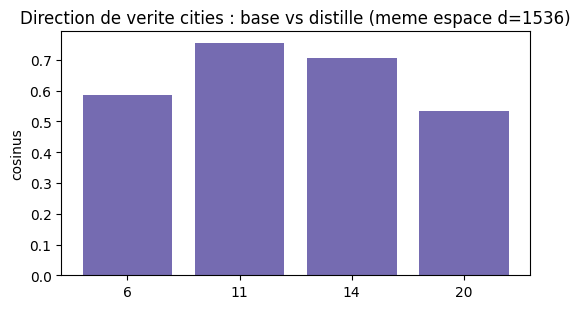

In [11]:
del model; torch.cuda.empty_cache()
model, tok = load_model("dist15")   # acts_for lit les globaux tok/model
ACTS_D = {}
t0 = time.time()
for key in ["cities", "neg_cities", "sp_en_trans"]:
    s, y = sample(key)
    st = [x if x.endswith(".") else x + "." for x in s]
    ACTS_D[key] = {"y": y, "acts": acts_for(st, CAP_LAYERS)}
print(f"extraction dist15 ({time.time()-t0:.0f}s)")
a_dist, _, _ = pca_stats(ACTS_D["cities"]["acts"][MID], ACTS_D["cities"]["y"])
print(f"pc1 cities dist15 = {a_dist} (base15 = {pca_stats(ACTS['cities']['acts'][MID], ACTS['cities']['y'])[0]})")

bridge = {}
for l in CAP_LAYERS:
    n = len(ACTS_D["cities"]["y"])
    Xb, yb = ACTS["cities"]["acts"][l][:n], ACTS["cities"]["y"][:n]
    Xd, yd = ACTS_D["cities"]["acts"][l], ACTS_D["cities"]["y"]
    tb = Xb[yb == 1].mean(0) - Xb[yb == 0].mean(0)
    td = Xd[yd == 1].mean(0) - Xd[yd == 0].mean(0)
    bridge[l] = round(float(tb @ td / (np.linalg.norm(tb) * np.linalg.norm(td))), 3)
print("cos(theta_mm base15, theta_mm dist15) par bloc :", bridge)
plt.figure(figsize=(5.5, 3.2))
plt.bar([str(l) for l in bridge], list(bridge.values()), color="#756bb1")
plt.axhline(0, color="k", lw=0.5); plt.ylabel("cosinus")
plt.title("Direction de verite cities : base vs distille (meme espace d=1536)")
plt.tight_layout(); plt.show()

### Lecture — pont distillation

Cosinus 0,54–0,76 selon la couche, jamais 1, jamais 0 : la direction de vérité `cities` est **partiellement héritée** par le modèle distillé. La distillation a conservé le squelette de la représentation factuelle (un axe vrai/faux dans la même région de l'espace) tout en la **réorientant** — cohérent avec ce qu'ICT-42 voyait du crosscoder : un socle de features partagées base↔distillé, et par-dessus des features distilled-only (les marqueurs de raisonnement). La direction de vérité appartient au **socle** — mais la ligne `pc1 cities` imprimée ci-dessus dit que le socle lui-même a été dilué (0,86 → 0,66 après distillation) : hériter d'une direction n'est pas préserver sa netteté.

## 6. Échelle : un regard 7B (quantifié)

Le papier fonde son claim d'émergence sur la comparaison 7B → 13B → 70B. Notre échelle s'arrête à 7B — en **4-bit nf4** (contrainte VRAM locale : ~6 GiB libres à côté des services résidents). Verdict SOTA honnête : c'est une **observation qualitative de tendance** — la quantification perturbe les activations, la fidélité de sonde à la fraction de pourcent près exigerait le bf16 sur une machine plus dotée (RECOVERABLE-MACHINE).

In [12]:
del model; torch.cuda.empty_cache()
model7, tok7 = load_model("dist7b", quant4=True)
nl7 = len(model7.model.layers); mid7 = nl7 // 2
print(f"dist7b 4-bit : {nl7} blocs, d={model7.config.hidden_size}, sonde au bloc {mid7}")

@torch.no_grad()
def acts7(statements, layer, batch=8, max_len=96):
    out = []
    for i in range(0, len(statements), batch):
        enc = tok7(statements[i:i+batch], return_tensors="pt", padding=True,
                   truncation=True, max_length=max_len).to(DEV)
        hs = model7(**enc, output_hidden_states=True).hidden_states
        out.append(hs[layer+1][:, -1, :].to(torch.float32).cpu().numpy())
    return np.concatenate(out, 0)

a7 = {}
t0 = time.time()
for key, n in [("cities", 400), ("neg_cities", 400), ("sp_en_trans", 354),
               ("neg_sp_en_trans", 354), ("larger_than", 300), ("smaller_than", 300)]:
    s, y = DS[key]
    idx = np.random.RandomState(SEED).choice(len(s), n, replace=False)
    st = [s[i] if s[i].endswith(".") else s[i] + "." for i in idx]
    a7[key] = (acts7(st, mid7), y[idx])
    print(f"acts7 {key} ({time.time()-t0:.0f}s)")

pca7 = {k: round(pca_stats(v[0], v[1])[0], 3) for k, v in a7.items()}
print("7B pc1_acc :", pca7)
Xtr7 = np.concatenate([a7["cities"][0], a7["neg_cities"][0]])
ytr7 = np.concatenate([a7["cities"][1], a7["neg_cities"][1]])
th7, mu7 = train_probes(Xtr7, ytr7)
gen7 = {p: {tk: round(probe_accuracy(t, mu7, a7[tk][0], a7[tk][1]), 2)
            for tk in ["sp_en_trans", "neg_sp_en_trans", "larger_than", "smaller_than"]}
        for p, t in th7.items()}
print("7B generalisation (train cities+neg) :", json.dumps(gen7, indent=1))
del model7; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

dist7b 4-bit : 28 blocs, d=3584, sonde au bloc 14


acts7 cities (257s)


acts7 neg_cities (527s)


acts7 sp_en_trans (748s)


acts7 neg_sp_en_trans (1000s)


acts7 larger_than (1152s)


acts7 smaller_than (1299s)


7B pc1_acc : {'cities': 0.512, 'neg_cities': 0.512, 'sp_en_trans': 0.915, 'neg_sp_en_trans': 0.955, 'larger_than': 0.507, 'smaller_than': 0.52}


7B generalisation (train cities+neg) : {
 "MM": {
  "sp_en_trans": 0.5,
  "neg_sp_en_trans": 0.5,
  "larger_than": 0.48,
  "smaller_than": 0.51
 },
 "LR": {
  "sp_en_trans": 0.51,
  "neg_sp_en_trans": 0.53,
  "larger_than": 0.64,
  "smaller_than": 0.55
 },
 "MMIID": {
  "sp_en_trans": 0.51,
  "neg_sp_en_trans": 0.51,
  "larger_than": 0.6,
  "smaller_than": 0.62
 }
}


### Lecture — échelle

Le tableau 7B converge qualitativement avec le papier : `cities` tombe à 0,51 (au hasard) alors que `sp_en` tient à 0,92 et `neg_sp_en` à 0,95 — le papier décrit le 7B comme captant des *clusters de surface* là où le 13B linéarise ; ici « surface » veut dire : la vérité est linéaire là où elle est mémoire directe (traductions), pas là où il faut calculer (villes : associer un pays). Et la généralisation `cities+neg_cities` → tests donne **MM au hasard (0,50 partout)**, LR devant (0,54–0,59) — l'inverse de la hiérarchie 1.5B et du papier à grande échelle : à 7B (et en 4-bit), la direction mass-mean n'est pas encore la bonne sonde. Rappelez la réserve de validité : nf4, une seule couche — **tendance, pas fraction**.

### Exercice 3 — sonde sur le non-curé (`common_claim`)

Tous nos tests jusqu'ici portaient sur des énoncés curés, simples, inambigus — le périmètre que le papier se donne (App A : la « vérité » = factualité d'énoncés déclaratifs simples ; pas le question-answering, pas la tromperie, pas la conformité). Le dataset `common_claim` (Casper et al., énoncés générés par GPT-3, étiquetés par des humains) sort de ce périmètre : énoncés ambigus, controversés, parfois mal formés. La sonde MM `cities+neg_cities` du 1.5B y résiste-t-elle ?

**Indices** : (1) téléchargez déjà fait — `DS['common_claim']` ; (2) sous-échantillonnez 400 énoncés, extrayez au bloc MID (réutilisez `acts_for` — pensez à recharger `base15` si le modèle 7B l'a évincé) ; (3) comparez l'accuracy à celle du même probe sur `sp_en_trans` ; (4) un accuracy proche du hasard n'est pas un échec de code : c'est la **limite de périmètre** du papier, mesurée sur nos modèles.

In [13]:
# Exercice 3 -- a completer
# 1. echantillonner common_claim
# 2. extraire les activations (recharger base15 au besoin)
# 3. mesurer probe_acc de la sonde MM cities+neg_cities
result = None  # TODO etudiant
print("Exercice a completer")

Exercice a completer


## Synthèse — ce que la chaîne a établi

La méthode trois jambes (une feature **suggère** / une sonde **décide** / une intervention **tranche**) appliquée à la vérité :

1. **Localisation** le verdict vit aux couches médianes, sur le pays et surtout le point final (argmax couche 13 = le token `'.'`, effet 0,88) ; 2. **Géométrie** vrai/faux est le premier axe pour villes/traductions (pc1 0,86) mais pas pour les nombres, dont les directions ancrées larger/smaller sont **antipodales** aux couches médianes (-0,89) puis s'alignent au bloc 20 (+0,84) ; 3. **Sondes** négation tue le transfert (0,49) ; énoncés+négations le réparent (0,74) et débloquent l'abstraction (MM 0,84 vs LR 0,46) ; le contrôle `likely` isole probabilité ≠ vérité ; 4. **Causalité** corrélation sans préhension causale forte à cette échelle (NIE ≤ 0,05 contre un patch à 0,88) ; l'ordre MM>LR réplique, les magnitudes non ; 5. **Pont distillation** direction partiellement héritée (cos 0,54–0,76) mais diluée (0,86 → 0,66) ; 6. **Échelle** le 7B quantifié confirme la trajectoire du papier (cities au hasard 0,51, traductions linéaires 0,92, MM au hasard en généralisation).

La réponse honnête à la question du titre : à notre échelle, la vérité d'un énoncé simple est une direction **lisible** dans le residual stream dès 1.5B — représentée, corrélée, transférable entre domaines via l'entraînement sur négations — mais **pas encore un levier causal** : la représenter n'est pas l'utiliser, et l'abstraction complète (un axe unique pour tous les domaines) reste un fait d'échelle. Et la réserve épistémique du papier reste la nôtre : une direction de vérité pour des énoncés **simples** n'est pas un détecteur de mensonge — R11 §2.2.2 veut détecter *le fait de connaître le vrai en affirmant le faux*, et ce notebook n'a mesuré que la première moitié : ce que le modèle représente, pas ce qu'il *choisit* d'affirmer.

## Limites

- **Échelle** : 1.5B principal, 7B en 4-bit qualitatif — le papier établit l'émergence à 7/13/70B bf16 ; nos verdicts sont des tendances à petite échelle.
- **Langue** : datasets anglais, modèles entraînés anglais ; la factualité FR (accords, genre) est un autre phénomène.
- **Périmètre vérité** : factualité d'énoncés simples (App A du papier) — pas QA, pas tromperie, pas conformité ; l'exercice 3 en mesure le bord.
- **Une couche de sonde** : bloc médian, choix du papier (13B → 15/32) transposé (28 → 14) ; l'alignement par couche (§2) montre que le choix n'est pas innocent.
- **Datasets non couverts (narrowing #16890)** : le depot officiel porte aussi `counterfact_true/false` et les conjonctions/disjonctions — le scoping d'origine les mentionnait. Ils ne sont pas charges ici : a 1.5B, trois datasets supplementaires d'extraction (x couches x ~500 enonces) alourdissaient le run pedagogique sans deplacer la question de transfert deja tranchee par les negations (0,49 -> 0,74). Le protocole `acts_for`/`train_probes` s'y applique tel quel — piste d'extension documentee, pas un trou muet.

## Références

- Marks & Tegmark, *The Geometry of Truth* (COLM 2024), arXiv:2310.06824 — datasets : `github.com/saprmarks/geometry-of-truth` (Geonames CC-BY ; sp_en : curation manuelle des auteurs ; companies : Azaria & Mitchell ; common_claim : Casper et al.).
- Notre arc : ICT-41 (issue #16747 — géométrie SAE) ; ICT-42 (issue #16749 — crosscoder R05, arXiv:2503.03730) ; R11 — Singapore Consensus (arXiv:2608.14611) §2.2.2 ; scoping #16760, grain #16890.
- Théorie : Thm F.1 (LR = Σ⁻¹θ en gaussien homoscédastique) ; LEACE / Belrose et al. (Thm G.1 : direction diff-in-means = effacement linéaire optimal de nullité 1).
- Meng, Bau, Andonian & Belinkov, *Locating and Editing Factual Associations in GPT* (ROME, NeurIPS 2022), arXiv:2202.05262 — la ligne cousine de notre carte de patching (section 1) : meme question (ou vit le fait ?), reponse par causal tracing puis *edition* des poids MLP ; ce notebook s'arrete a l'observation, l'edition reste hors perimetre.